# Does ingestion memory remain bounded by chunk size?

This notebook tests whether a fixed 100,000-row chunk keeps the Python process memory approximately bounded as more source rows are ingested. The suspected source of retained state is the pair of Python sets used to deduplicate responsible-party and beneficiary identifiers across chunks.

## Hypothesis and interpretation boundary

**Hypothesis:** if memory is controlled only by the current chunk, post-cleanup RSS should stabilize while the chunk size remains fixed. If post-cleanup RSS grows with accumulated distinct identifiers, the pipeline is not memory-bounded by chunk size.

RSS is process-level resident memory. It includes Python, native libraries, allocator reserves, DataFrames, driver buffers, and the deduplication sets. Correlation between set cardinality and RSS supports the hypothesis but does not isolate causality; allocator behavior is a competing explanation. PostgreSQL memory is outside this measurement.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
from analysis.ingestion_memory import (
    aggregate_memory_trajectory,
    load_memory_experiment,
    measured_memory_chunks,
    summarize_memory_runs,
    write_public_memory_summary,
)

MANIFEST_PATH = PROJECT_ROOT / "artifacts/ingestion-memory/manifest.json"
SUMMARY_PATH = PROJECT_ROOT / "results/ingestion-memory-summary.csv"
plt.style.use("seaborn-v0_8-whitegrid")

In [3]:
chunks, metadata = load_memory_experiment(MANIFEST_PATH)
measured = measured_memory_chunks(chunks)
trajectory = aggregate_memory_trajectory(chunks)
summary = summarize_memory_runs(chunks)
write_public_memory_summary(summary, SUMMARY_PATH)

protocol = pd.DataFrame(
    {
        "chunk_size": [metadata["chunk_size"]],
        "input_sizes": [metadata["sizes"]],
        "warmups_per_size": [metadata["warmups"]],
        "measured_runs_per_size": [metadata["repetitions"]],
        "measured_chunk_checkpoints": [len(measured)],
    }
)
protocol

,chunk_size,input_sizes,warmups_per_size,measured_runs_per_size,measured_chunk_checkpoints
0,100000,"[100000, 1000000, 5000000]",1,3,183


## Protocol

Each input size has one warm-up and three measured runs. Every run starts from a newly migrated database. The input file, schema, transformations, PostgreSQL instance, chunk size, and runner remain fixed. Warm-ups are validated but excluded from all statistics below.

The 100,000-row scenario contains only one chunk and therefore cannot reveal between-chunk growth. The 1-million and 5-million scenarios provide 10 and 50 checkpoints per run.

In [4]:
summary.round(3)

,source_rows,repetitions,chunks,initial_rss_mb,first_cleanup_rss_mb,final_cleanup_rss_mb,cleanup_rss_growth_mb,total_rss_growth_mb,final_deduplication_identifiers,cleanup_rss_deduplication_correlation,mib_per_million_deduplication_identifiers
0,100000,3,1,143.777,183.480,183.480,0.000,40.117,114035,NaN,NaN
1,1000000,3,10,143.723,183.402,333.496,150.664,189.578,1062908,0.958,129.965
2,5000000,3,50,142.402,181.938,749.750,567.812,607.652,5436256,0.991,106.619


The summary reports medians across the three measured runs. `cleanup_rss_growth_mb` compares the first and last post-cleanup checkpoints, while `total_rss_growth_mb` compares process memory before the first CSV read with memory after the final cleanup. The correlation and slope are descriptive associations, not causal estimates.

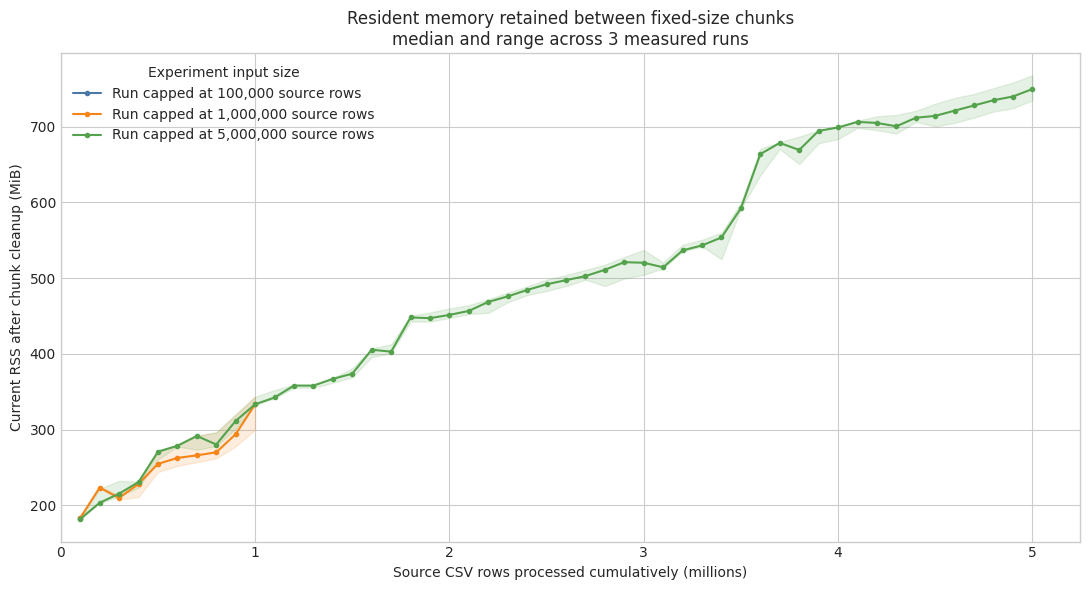

In [5]:
fig, ax = plt.subplots(figsize=(11, 6))
colors = {100_000: "#4c78a8", 1_000_000: "#f58518", 5_000_000: "#54a24b"}

for source_rows, group in trajectory.groupby("source_rows", sort=True):
    x = group["processed_rows"] / 1_000_000
    median = group["current_rss_after_cleanup_mb_median"]
    minimum = group["current_rss_after_cleanup_mb_min"]
    maximum = group["current_rss_after_cleanup_mb_max"]
    label = f"Run capped at {source_rows:,} source rows"
    ax.plot(x, median, marker="o", markersize=3, color=colors[source_rows], label=label)
    ax.fill_between(x, minimum, maximum, color=colors[source_rows], alpha=0.14)

ax.set_title("Resident memory retained between fixed-size chunks\nmedian and range across 3 measured runs")
ax.set_xlabel("Source CSV rows processed cumulatively (millions)")
ax.set_ylabel("Current RSS after chunk cleanup (MiB)")
ax.legend(title="Experiment input size")
ax.set_xlim(left=0)
plt.tight_layout()
plt.show()

Post-cleanup RSS does not stabilize. In the 5-million-row experiment, the median rises from about 182 MiB after the first chunk to about 750 MiB after the fiftieth chunk. Because all chunks contain at most 100,000 source rows, the retained process memory depends on accumulated work rather than only on the current chunk.

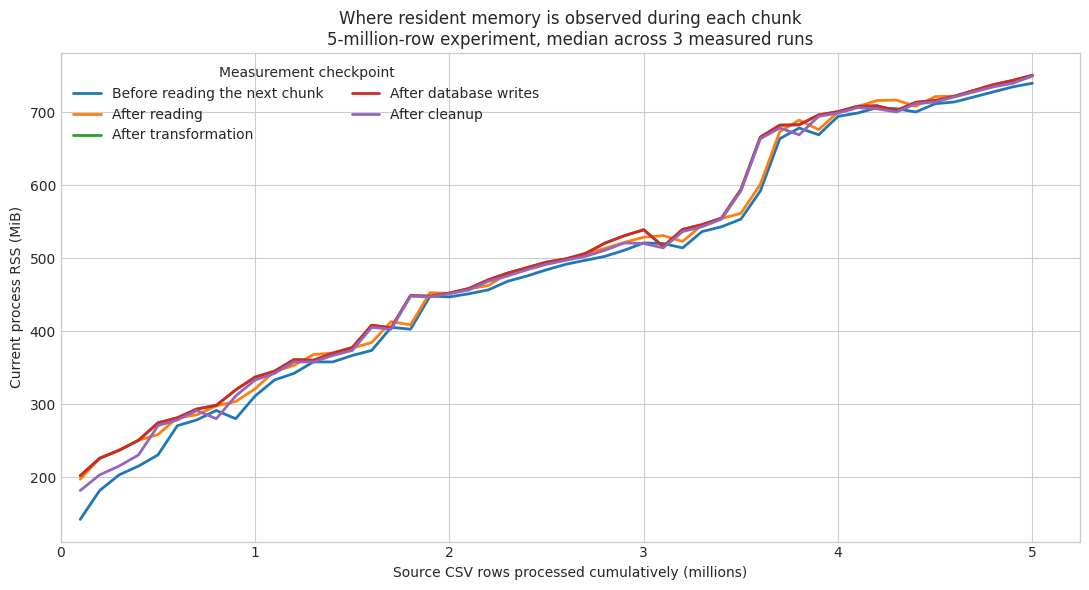

In [6]:
largest = measured.loc[measured["source_rows"] == measured["source_rows"].max()].copy()
largest["processed_millions"] = largest["processed_rows"] / 1_000_000

checkpoint_columns = {
    "Before reading the next chunk": "current_rss_before_read_mb",
    "After reading": "current_rss_after_read_mb",
    "After transformation": "current_rss_after_transform_mb",
    "After database writes": "current_rss_after_write_mb",
    "After cleanup": "current_rss_after_cleanup_mb",
}
checkpoint_medians = largest.groupby("processed_millions")[list(checkpoint_columns.values())].median()

fig, ax = plt.subplots(figsize=(11, 6))
for label, column in checkpoint_columns.items():
    ax.plot(checkpoint_medians.index, checkpoint_medians[column], label=label, linewidth=2)
ax.set_title("Where resident memory is observed during each chunk\n5-million-row experiment, median across 3 measured runs")
ax.set_xlabel("Source CSV rows processed cumulatively (millions)")
ax.set_ylabel("Current process RSS (MiB)")
ax.legend(title="Measurement checkpoint", ncols=2)
ax.set_xlim(left=0)
plt.tight_layout()
plt.show()

The checkpoint curves converge as the experiment progresses: the temporary increase caused by one more chunk becomes small relative to the retained baseline. This does not mean reading and transformation allocate no memory; it means the allocator can reuse memory already resident in the process. `after_cleanup` remains the key checkpoint for testing whether the next iteration begins from a stable baseline.

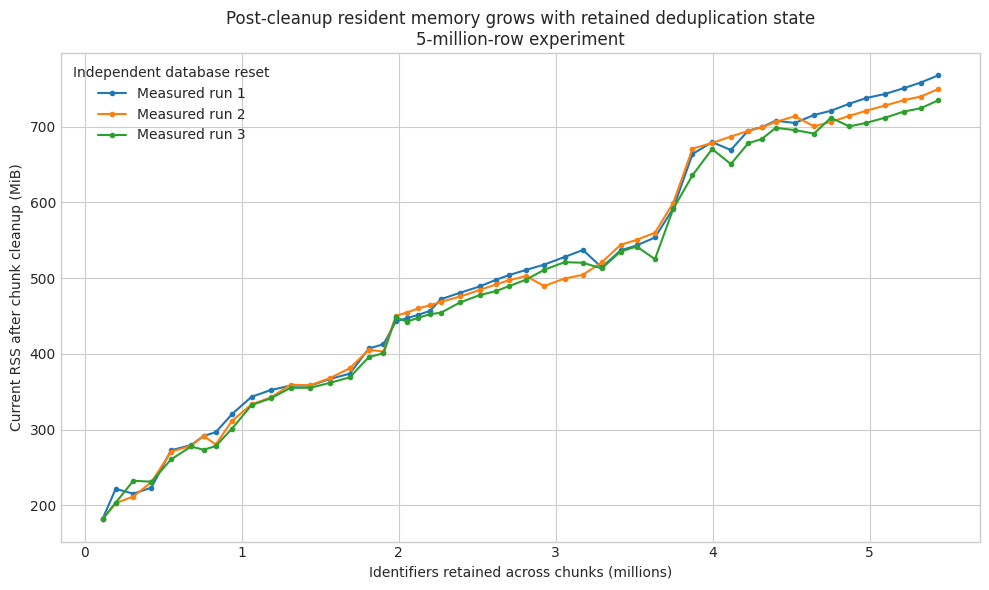

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
for run, group in largest.groupby("run"):
    ordered = group.sort_values("deduplication_identifiers")
    ax.plot(
        ordered["deduplication_identifiers"] / 1_000_000,
        ordered["current_rss_after_cleanup_mb"],
        marker="o",
        markersize=3,
        label=f"Measured run {run}",
    )
ax.set_title("Post-cleanup resident memory grows with retained deduplication state\n5-million-row experiment")
ax.set_xlabel("Identifiers retained across chunks (millions)")
ax.set_ylabel("Current RSS after chunk cleanup (MiB)")
ax.legend(title="Independent database reset")
plt.tight_layout()
plt.show()

Across the three 5-million-row runs, the median Pearson correlation between post-cleanup RSS and retained identifier count is approximately 0.991. A simple descriptive linear fit gives about 107 MiB of additional RSS per million accumulated identifiers. Both variables also grow with processing progress, so these values quantify association rather than prove that the sets alone caused every additional MiB.

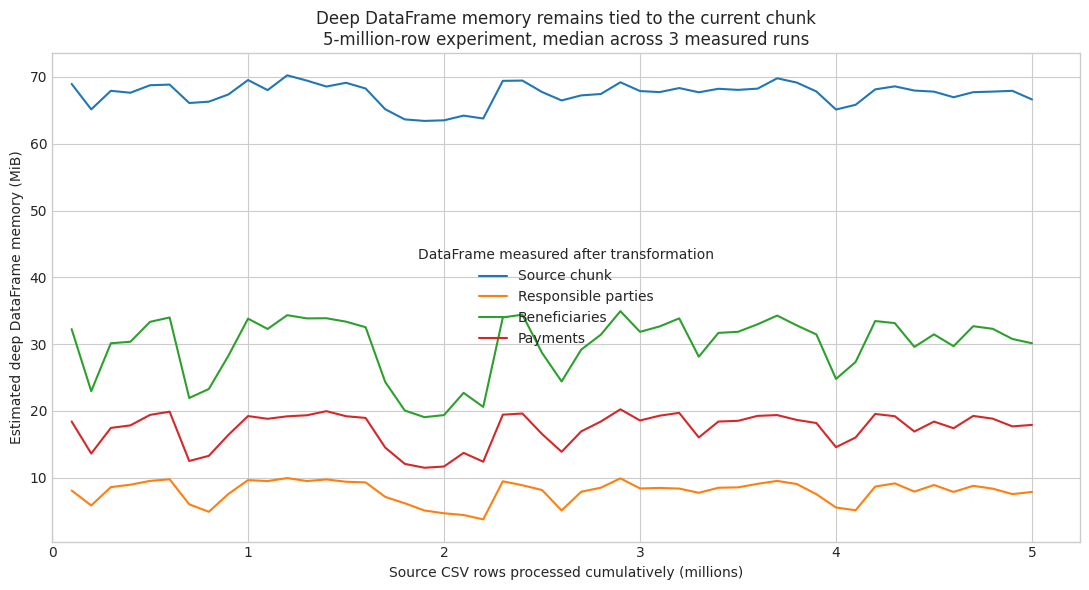

In [8]:
dataframe_columns = {
    "Source chunk": "dataframe_source_chunk_mb",
    "Responsible parties": "dataframe_responsavel_mb",
    "Beneficiaries": "dataframe_beneficiario_mb",
    "Payments": "dataframe_auxilio_mb",
}
dataframe_medians = largest.groupby("processed_millions")[list(dataframe_columns.values())].median()

fig, ax = plt.subplots(figsize=(11, 6))
for label, column in dataframe_columns.items():
    ax.plot(dataframe_medians.index, dataframe_medians[column], label=label)
ax.set_title("Deep DataFrame memory remains tied to the current chunk\n5-million-row experiment, median across 3 measured runs")
ax.set_xlabel("Source CSV rows processed cumulatively (millions)")
ax.set_ylabel("Estimated deep DataFrame memory (MiB)")
ax.legend(title="DataFrame measured after transformation")
ax.set_xlim(left=0)
plt.tight_layout()
plt.show()

`DataFrame.memory_usage(deep=True)` estimates each DataFrame independently. Object-backed columns can share Python string objects, so these estimates must not be summed and interpreted as physical RSS. Their approximately stable scale is still useful: the DataFrame inputs remain associated with a fixed-size chunk while post-cleanup process RSS continues to grow.

## Conclusion

The current ingestion is **not memory-bounded by its 100,000-row chunk size**. Median post-cleanup RSS grows by about 568 MiB between the first and last chunks of the 5-million-row experiment, reaching roughly 750 MiB while retaining about 5.44 million identifiers. The result is reproducible across three independent runs.

The evidence is consistent with the code-level diagnosis that global deduplication sets retain state proportional to accumulated distinct identifiers. Allocator retention prevents assigning all RSS growth exclusively to those sets, so the causal test is a controlled refactor: move cross-chunk deduplication to PostgreSQL staging, repeat this protocol, and compare the post-cleanup trajectory.

The 100,000-row scenario is a smoke measurement, not evidence about growth. The 1-million-row result shows the same direction, while the 5-million-row result provides the strongest trajectory.